### Population Growth Model
$\frac{dP(t)}{dt}=rP(t)(1-\frac{P(t)}{K})$

r: growth rate (r=0.5)

K: capacity (K=100)

P(0)=50

In [1]:
import torch
import torch.nn as nn
import mlp
import utils
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# actual solution
K = 100
r = 0.5
pini = 50
t = torch.linspace(0, 10, 100).to(device).reshape(-1, 1)
p_sol = K * torch.exp(r*t) / (1 + torch.exp(r*t))

# nn
num_hidden = 2
num_nodes = 8

layer_list = [1] + [num_nodes] * num_hidden + [1]
model = mlp.pinn(layer_list).to(device)

In [3]:
lr = 1e-2
num_epochs = 5000
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [ ]:
loss_graph = []

t_req = t.clone()
t_req.requires_grad = True

for _ in range(num_epochs):
    optimizer.zero_grad()
    
    p0_pred = model(t[0:1])
    p_pred = model(t_req)
    
    loss_col = torch.mean(utils.population_growth(p_pred, t_req)**2)
    loss_max = torch.max(utils.population_growth(p_pred, t_req)**2) # avoid trivial solutions (zero)
    loss_ini = torch.mean((p0_pred - pini)**2)
    loss = loss_col + loss_ini + loss_max
    loss.backward()
    optimizer.step()
    
    loss_graph.append(loss.item())

print(f'mse: {loss_graph[-1]}')
print(f'p0_pred: {p0_pred.item()}')
torch.save(model.state_dict(), './param/population_growth.pth')

c:\Users\skcjf\project\self-study\CUDA Programming and Pytorch\pytorch\.venv\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


mse: 0.00141999963670969
p0_pred: 49.9786376953125


In [5]:
model.load_state_dict(torch.load('./param/population_growth.pth'))

with torch.no_grad():
    p_pred = model(t)

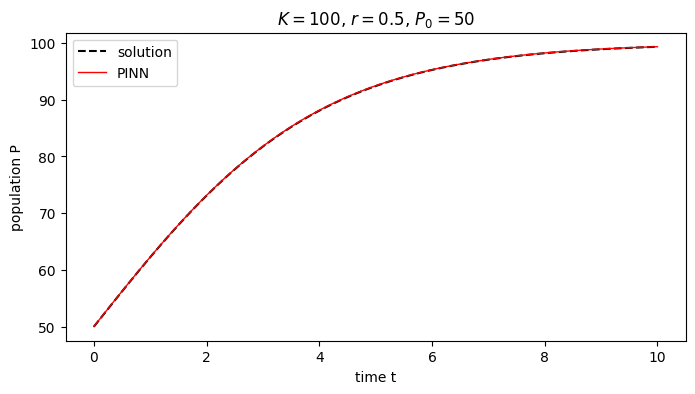

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(t.cpu().numpy(),p_sol.cpu().numpy(),'--',color='black')
plt.plot(t.cpu().numpy(),p_pred.detach().cpu().numpy(),color='red',linewidth=1)
plt.legend(['solution','PINN'])
plt.ylabel('population P')
plt.xlabel('time t')
plt.title(rf'$K={K}$, $r={r}$, $P_0={pini}$')
plt.show()